# 04 · Mesa's uncertainty signal

Mesa's exact solve computes `q* = (H_t + Λ)⁻¹ q_t` inside its forward pass. The
scalar `u_t = q_tᵀ q*` is a free byproduct. This checks whether `u_t` tracks
held-out prediction error on clean in-context regression.

One trained Mesa (CG=30) model, one held-out eval set, one figure. The solve runs
inside fla's Triton kernel, so we capture the kernel's inputs by patching
`chunk_mesa_net` and recompute `q*` with fla's exact reference.

/home/vzer/Documents/phd/linear_rnn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


19200 query points   global rho = 0.362   partial rho|depth = 0.020


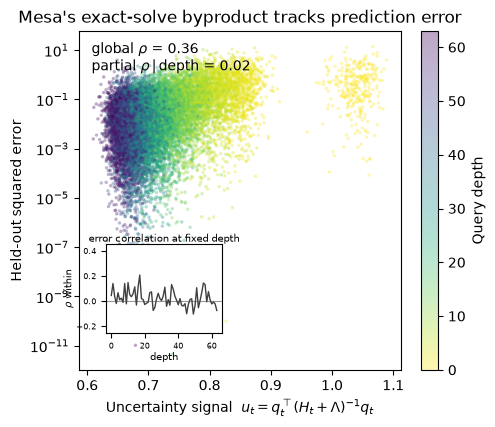

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import torch
import matplotlib.pyplot as plt
from compare.model import ModelConfig, SequenceModel
from compare.train import _to_tensors, _masked_loss, set_seed
from compare.experiments import train_regression_model
from synthtasks.regression import make_regression
import fla.layers.mesa_net as mn
from fla.modules.l2norm import l2_norm

DEV = "cuda" if torch.cuda.is_available() else "cpu"
DT = torch.bfloat16 if DEV == "cuda" else torch.float32
D, EVAL = 8, [4, 8, 12, 16, 24, 32, 48, 64]
N_EX, N_SEQ, GROUP, STEPS, SEED = 64, 300, 50, 600, 0


def mesa_qstar(q, k, g, lamb, beta):
    """Exact per-token Mesa solve (fla naive_mesa_net_exact). Returns q* = (H_t+Λ)^-1 q_t; shape (B,L,h,d)."""
    B, L, h, d = q.shape
    q, k, g, lamb, beta = (t.float() for t in (q, k, g, lamb, beta))
    h_kk = torch.zeros(B, h, d, d, device=q.device)
    Hkk = torch.empty(B, L, h, d, d, device=q.device)
    for i in range(L):
        kb = k[:, i] * beta[:, i, :, None]
        h_kk = h_kk * g[:, i, :, None, None].exp() + kb[..., None] * k[:, i, :, None, :]
        Hkk[:, i] = h_kk
    return torch.linalg.solve(Hkk + torch.diag_embed(lamb)[None, None], q)


def spearman(a, b):
    """Spearman rho via Pearson of ranks."""
    ra, rb = a.argsort().argsort().astype(float), b.argsort().argsort().astype(float)
    return float(np.corrcoef(ra, rb)[0, 1])


# train (or reload from disk) one Mesa CG=30 model on clean regression (nb01 config).
# Λ is the trained value (mesa_lambda unset); u_t degenerates if Λ is forced large.
# train_regression_model disk-caches the weights, so re-runs reload instead of retrain.
model = train_regression_model(noise=0.0, train_knobs=EVAL, d=D, cg_steps=30,
                               steps=STEPS, seed=SEED, device=DEV, dtype=DT)

# capture the exact tensors fed to the solve kernel (q* is discarded inside it)
caps = []
_orig = mn.chunk_mesa_net
def _cap(*a, **k):
    caps.append({n: k[n].detach() for n in ("q", "k", "g", "beta", "lamb")})
    return _orig(*a, **k)
mn.chunk_mesa_net = _cap

# held-out eval (disjoint seeds): log (u_t, squared error, query depth) per query
us, errs, depths = [], [], []
for g0 in range(0, N_SEQ, GROUP):
    bs = min(GROUP, N_SEQ - g0)
    inp, tgt, _ = make_regression(batch=bs, n_examples=N_EX, d=D, noise=0.0, drift=0.0, seed=1_000_000 + g0)
    caps.clear()
    with torch.no_grad():
        pred = model(_to_tensors(inp, "continuous", DEV, DT)).float().cpu().numpy()
    c = caps[-1]                                      # last Mesa layer (feeds the readout)
    qn, kn = l2_norm(c["q"].float()), l2_norm(c["k"].float())   # kernel L2-norms q,k internally
    qstar = mesa_qstar(qn, kn, c["g"], c["lamb"], c["beta"])
    u = (qn * qstar).sum(-1).mean(-1).cpu().numpy()   # u_t = q_t^T q_t*, averaged over heads
    ev = slice(0, 2 * N_EX, 2)                         # even positions = scored queries
    us.append(u[:, ev].ravel())
    errs.append(((pred[:, ev] - tgt[:, ev]) ** 2).ravel())
    depths.append(np.tile(np.arange(N_EX), bs))
mn.chunk_mesa_net = _orig

u = np.concatenate(us)
err = np.concatenate(errs)
depth = np.concatenate(depths)
rho = spearman(u, err)
# partial Spearman controlling for depth: residualize global ranks within each depth
ru, re = u.argsort().argsort().astype(float), err.argsort().argsort().astype(float)
for d in np.unique(depth):
    msk = depth == d
    ru[msk] -= ru[msk].mean(); re[msk] -= re[msk].mean()
prho = float(np.corrcoef(ru, re)[0, 1])
rhos = np.array([spearman(u[depth == d], err[depth == d]) for d in np.unique(depth)])
print(f"{u.size} query points   global rho = {rho:.3f}   partial rho|depth = {prho:.3f}")

# figure: u_t vs error, colored by query depth; inset = within-depth correlation
fig, ax = plt.subplots(figsize=(5.2, 4.4))
sc = ax.scatter(u, err, c=depth, cmap="viridis_r", s=6, alpha=0.35, edgecolors="none")
ax.set_yscale("log")                                  # error spans decades; u does not -> linear x
ax.set_xlabel(r"Uncertainty signal  $u_t = q_t^\top (H_t+\Lambda)^{-1} q_t$")
ax.set_ylabel("Held-out squared error")
ax.set_title("Mesa's exact-solve byproduct tracks prediction error")
ax.text(0.04, 0.97, f"global $\\rho$ = {rho:.2f}\npartial $\\rho\\,|\\,$depth = {prho:.2f}",
        transform=ax.transAxes, va="top", fontsize=10)
fig.colorbar(sc, ax=ax).set_label("Query depth")

# within-depth rho vs depth: ~0 everywhere -> the correlation is in-context evidence, not per-query
ins = ax.inset_axes([0.085, 0.11, 0.36, 0.26])
ins.axhline(0, color="0.6", lw=0.8)
ins.plot(np.unique(depth), rhos, "-", color="0.25", lw=1)
ins.set_ylim(-0.25, 0.45)
ins.set_xlabel("depth", fontsize=7, labelpad=1)
ins.set_ylabel(r"$\rho$ within", fontsize=7, labelpad=1)
ins.tick_params(labelsize=6)
ins.set_title("error correlation at fixed depth", fontsize=7, pad=2)

fig.savefig("figures/04_mesa_uncertainty_signal.png", dpi=600, bbox_inches="tight")
plt.show()

## Noisy regression — does `u_t` resolve error within depth?

Repeat with label noise (σ=0.5). `u_t` depends only on the demo inputs (the key Gram), not the labels, so noise cannot change `u_t`; the question is whether the persistent error variance lets `u_t` resolve per-query error at fixed depth.

sigma=0.5: global rho=0.133  partial rho|depth=-0.006  median CoV(u|depth)=0.014


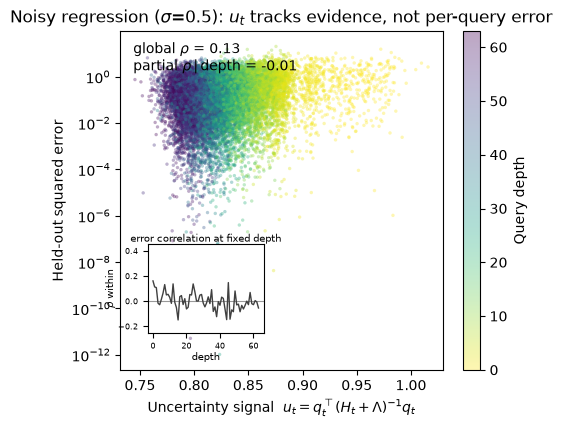

In [2]:
NOISE = 0.5
# reuse the disk-cached trainer (see Experiment 1); reloads if already trained
m2 = train_regression_model(noise=NOISE, train_knobs=EVAL, d=D, cg_steps=30,
                            steps=STEPS, seed=0, device=DEV, dtype=DT)

caps2 = []
_orig2 = mn.chunk_mesa_net
def _cap2(*a, **k):
    caps2.append({n: k[n].detach() for n in ("q", "k", "g", "beta", "lamb")})
    return _orig2(*a, **k)
mn.chunk_mesa_net = _cap2
us, errs, depths = [], [], []
for g0 in range(0, N_SEQ, GROUP):
    bs = min(GROUP, N_SEQ - g0)
    inp, tgt, _ = make_regression(batch=bs, n_examples=N_EX, d=D, noise=NOISE, drift=0.0, seed=1_000_000 + g0)
    caps2.clear()
    with torch.no_grad():
        pred = m2(_to_tensors(inp, "continuous", DEV, DT)).float().cpu().numpy()
    c = caps2[-1]
    qn, kn = l2_norm(c["q"].float()), l2_norm(c["k"].float())
    u = (qn * mesa_qstar(qn, kn, c["g"], c["lamb"], c["beta"])).sum(-1).mean(-1).cpu().numpy()
    ev = slice(0, 2 * N_EX, 2)
    us.append(u[:, ev].ravel())
    errs.append(((pred[:, ev] - tgt[:, ev]) ** 2).ravel())
    depths.append(np.tile(np.arange(N_EX), bs))
mn.chunk_mesa_net = _orig2

u = np.concatenate(us); err = np.concatenate(errs); depth = np.concatenate(depths)
rho = spearman(u, err)
ru, re = u.argsort().argsort().astype(float), err.argsort().argsort().astype(float)
for d in np.unique(depth):
    msk = depth == d
    ru[msk] -= ru[msk].mean(); re[msk] -= re[msk].mean()
prho = float(np.corrcoef(ru, re)[0, 1])
rhos = np.array([spearman(u[depth == d], err[depth == d]) for d in np.unique(depth)])
cov = float(np.median([u[depth == d].std() / u[depth == d].mean() for d in np.unique(depth)]))
print(f"sigma={NOISE}: global rho={rho:.3f}  partial rho|depth={prho:.3f}  median CoV(u|depth)={cov:.3f}")

fig, ax = plt.subplots(figsize=(5.2, 4.4))
sc = ax.scatter(u, err, c=depth, cmap="viridis_r", s=6, alpha=0.35, edgecolors="none")
ax.set_yscale("log")
ax.set_xlabel(r"Uncertainty signal  $u_t = q_t^\top (H_t+\Lambda)^{-1} q_t$")
ax.set_ylabel("Held-out squared error")
ax.set_title(rf"Noisy regression ($\sigma$={NOISE}): $u_t$ tracks evidence, not per-query error")
ax.text(0.04, 0.97, f"global $\\rho$ = {rho:.2f}\npartial $\\rho\\,|\\,$depth = {prho:.2f}",
        transform=ax.transAxes, va="top", fontsize=10)
fig.colorbar(sc, ax=ax).set_label("Query depth")
ins = ax.inset_axes([0.085, 0.11, 0.36, 0.26])
ins.axhline(0, color="0.6", lw=0.8)
ins.plot(np.unique(depth), rhos, "-", color="0.25", lw=1)
ins.set_ylim(-0.25, 0.45)
ins.set_xlabel("depth", fontsize=7, labelpad=1)
ins.set_ylabel(r"$\rho$ within", fontsize=7, labelpad=1)
ins.tick_params(labelsize=6)
ins.set_title("error correlation at fixed depth", fontsize=7, pad=2)
fig.savefig("figures/04_mesa_uncertainty_signal_noisy.png", dpi=600, bbox_inches="tight")
plt.show()

## Experiment 2 — MQAR with distractors (directional data)

MQAR is intrinsically directional (discrete keys → anisotropic `H_t`). This experiment tests whether `u_t` separates correct from incorrect retrievals.

queries=4000  acc=0.963  incorrect=149  AUROC(u->correct)=0.796


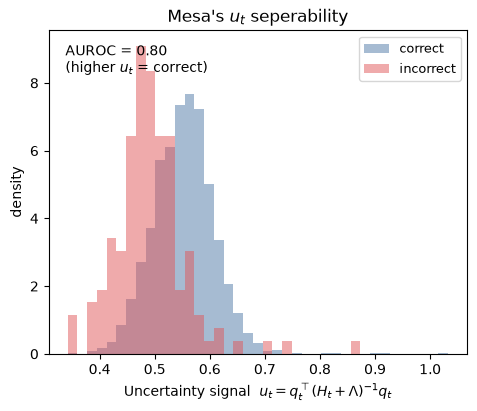

In [6]:
from compare.experiments import MQARConfig, train_mqar
from synthtasks.mqar import make_mqar

VOCAB, NQ, NPAIRS, GAP, ND = 128, 4, 8, 2, 64
GDN_RET = float(torch.sigmoid(torch.tensor(4.0)))
# distractor-MQAR Mesa CG=30 (nb03 config); trained Λ
cfg_mq = MQARConfig(vocab=VOCAB, n_queries=NQ, train_pairs=(NPAIRS,), train_gaps=(GAP,),
                    train_distractors=(0, 8, 16, 32, 64), steps=3000, hidden_size=128, num_heads=4,
                    num_layers=2, eval_batches=8, device=DEV, mesa_retention_init=4.0, gdn_retention_init=GDN_RET)
mq = train_mqar("mesa", 30, cfg_mq, seed=0).model
mq.eval()


def auroc(score, pos):
    """AUROC of score as a predictor of pos (P(score_pos > score_neg))."""
    order = score.argsort()
    ranks = np.empty(len(score)); ranks[order] = np.arange(len(score))
    npos, nneg = int(pos.sum()), int((~pos).sum())
    return (ranks[pos].sum() - npos * (npos - 1) / 2) / (npos * nneg)


# held-out eval at high distractor load; reuse the Experiment-1 hook (mesa_qstar) for u_t
caps = []
_orig = mn.chunk_mesa_net
def _cap(*a, **k):
    caps.append({n: k[n].detach() for n in ("q", "k", "g", "beta", "lamb")})
    return _orig(*a, **k)
mn.chunk_mesa_net = _cap
us, corr, done = [], [], 0
while done < 1000:
    bs = min(50, 1000 - done)
    inp, tgt, msk = make_mqar(bs, NPAIRS, NQ, GAP, VOCAB, 5_000_000 + done, n_distractors=ND)
    caps.clear()
    with torch.no_grad():
        pred = mq(torch.as_tensor(inp, dtype=torch.long, device=DEV)).float().argmax(-1).cpu().numpy()
    c = caps[-1]
    qn, kn = l2_norm(c["q"].float()), l2_norm(c["k"].float())
    uh = (qn * mesa_qstar(qn, kn, c["g"], c["lamb"], c["beta"])).sum(-1).cpu().numpy()  # (B,L,h) per head
    m = np.asarray(msk, bool)
    us.append(uh[m]); corr.append((pred == np.asarray(tgt))[m]); done += bs
mn.chunk_mesa_net = _orig

U = np.concatenate(us); correct = np.concatenate(corr)   # U: (queries, n_heads)
u = U.mean(1)             # head-averaged u_t (the figure)
roc = auroc(u, correct)   # u_t as a predictor of correctness
print(f"queries={u.size}  acc={correct.mean():.3f}  incorrect={(~correct).sum()}  AUROC(u->correct)={roc:.3f}")

bins = np.linspace(u.min(), u.max(), 40)
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.hist(u[correct], bins=bins, density=True, alpha=0.5, color="#4e79a7", label="correct")
ax.hist(u[~correct], bins=bins, density=True, alpha=0.5, color="#e15759", label="incorrect")
ax.set_xlabel(r"Uncertainty signal  $u_t = q_t^\top (H_t+\Lambda)^{-1} q_t$")
ax.set_ylabel("density")
ax.set_title("Mesa's $u_t$ seperability")
ax.text(0.04, 0.96, f"AUROC = {roc:.2f}\n(higher $u_t$ = correct)", transform=ax.transAxes, va="top", fontsize=10)
ax.legend(loc="upper right", fontsize=9)
fig.savefig("figures/04b_mesa_uncertainty_mqar.png", dpi=600, bbox_inches="tight")
plt.show()

## Per-head view

Per-head AUROC of `u_t` as a predictor of retrieval correctness; the best head is highlighted.

per-head AUROC: [0.546 0.857 0.525 0.886]   best head 3 = 0.886   head-mean = 0.817


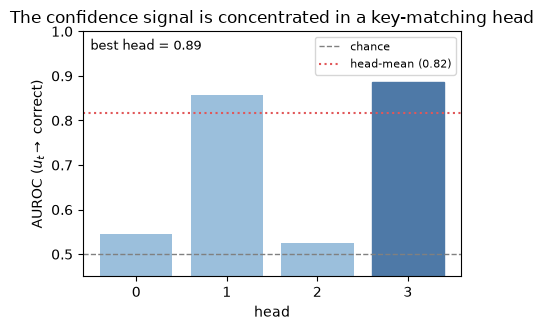

In [4]:
head_auc = np.array([auroc(U[:, h], correct) for h in range(U.shape[1])])
best = int(head_auc.argmax())
print("per-head AUROC:", np.round(head_auc, 3),
      f"  best head {best} = {head_auc[best]:.3f}   head-mean = {roc:.3f}")

fig, ax = plt.subplots(figsize=(4.6, 3.4))
bars = ax.bar(np.arange(len(head_auc)), head_auc, color="#9bbfdc")
bars[best].set_color("#4e79a7")                       # highlight the key-matching head
ax.axhline(0.5, color="gray", ls="--", lw=1, label="chance")
ax.axhline(roc, color="#e15759", ls=":", lw=1.5, label=f"head-mean ({roc:.2f})")
ax.text(0.02, 0.97, f"best head = {head_auc[best]:.2f}", transform=ax.transAxes,
        va="top", ha="left", fontsize=9)
ax.set_xticks(np.arange(len(head_auc)))
ax.set_xlabel("head")
ax.set_ylabel(r"AUROC ($u_t \to$ correct)")
ax.set_ylim(0.45, 1.0)                                 # headroom so labels clear the bars
ax.set_title("The confidence signal is concentrated in a key-matching head")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
fig.savefig("figures/04c_mesa_uncertainty_mqar_heads.png", dpi=600, bbox_inches="tight")
plt.show()

## Verification — are the errors distractor collisions?

The cell checks two things — the nearest-distractor cosine of each query split by correctness, and whether the top eigendirections of `H_t` are built from distractor keys — and plots the nearest-distractor cosine split by correctness.

nearest-distractor cosine: correct=0.165  incorrect=0.236
AUROC(distractor cosine -> incorrect) = 0.600
top-8 eigenspace energy: distractor keys=0.960  target keys=0.842  (distractor > target => distractor-built)


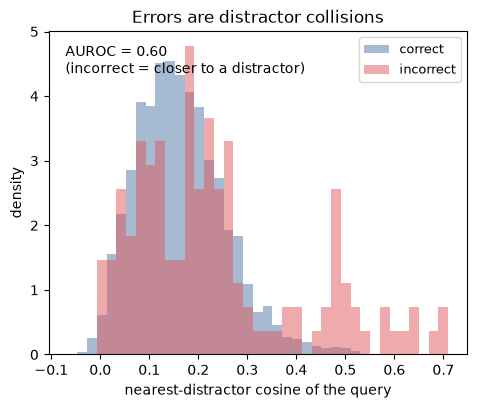

In [5]:
TK = list(range(0, 2 * NPAIRS, 2))                       # target key positions
DK = list(range(2 * NPAIRS, 2 * NPAIRS + 2 * ND, 2))     # distractor key positions
QS = 2 * NPAIRS + 2 * ND + GAP                           # query block start
QP = list(range(QS, QS + NQ))                            # query positions
K_TOP = 8


def state_H(q, k, g, beta):
    """Per-token state H_t = sum of decayed k kᵀ; shape (B,L,h,d,d)."""
    B, L, h, d = q.shape
    q, k, g, beta = q.float(), k.float(), g.float(), beta.float()
    hk = torch.zeros(B, h, d, d, device=q.device); H = torch.empty(B, L, h, d, d, device=q.device)
    for i in range(L):
        kb = k[:, i] * beta[:, i, :, None]
        hk = hk * g[:, i, :, None, None].exp() + kb[..., None] * k[:, i, :, None, :]; H[:, i] = hk
    return H


caps = []
_orig = mn.chunk_mesa_net
def _cap(*a, **k):
    caps.append({n: k[n].detach() for n in ("q", "k", "g", "beta", "lamb")})
    return _orig(*a, **k)
mn.chunk_mesa_net = _cap

cos_ov, ok2, ed, et, nb, done = [], [], 0.0, 0.0, 0, 0
while done < 1000:
    bs = min(50, 1000 - done)
    inp, tgt, msk = make_mqar(bs, NPAIRS, NQ, GAP, VOCAB, 5_000_000 + done, n_distractors=ND)
    caps.clear()
    with torch.no_grad():
        pred = mq(torch.as_tensor(inp, dtype=torch.long, device=DEV)).float().argmax(-1).cpu().numpy()
    c = caps[-1]
    qn, kn = l2_norm(c["q"].float()), l2_norm(c["k"].float())
    # nearest-distractor cosine of each query (head-averaged)
    cos = torch.einsum("bqhd,bnhd->bqnh", qn[:, QP], kn[:, DK]).max(dim=2).values.mean(-1).cpu().numpy()
    cos_ov.append(cos.ravel())
    ok2.append((pred[:, QP] == np.asarray(tgt)[:, QP]).ravel())
    # are the top-K eigendirections of H_t distractor-built? energy of each key type in that subspace
    V0 = torch.linalg.eigh(state_H(qn, kn, c["g"], c["beta"])[:, QS]).eigenvectors[..., -K_TOP:]
    en = lambda K: (torch.einsum("bmhd,bhdk->bmhk", K, V0) ** 2).sum(-1).mean().item()
    ed += en(kn[:, DK]); et += en(kn[:, TK]); nb += 1
    done += bs
mn.chunk_mesa_net = _orig

cos = np.concatenate(cos_ov); correct2 = np.concatenate(ok2); inc = ~correct2
print(f"nearest-distractor cosine: correct={cos[correct2].mean():.3f}  incorrect={cos[inc].mean():.3f}")
print(f"AUROC(distractor cosine -> incorrect) = {auroc(cos, inc):.3f}")
print(f"top-{K_TOP} eigenspace energy: distractor keys={ed/nb:.3f}  target keys={et/nb:.3f}  (distractor > target => distractor-built)")

bins = np.linspace(cos.min(), cos.max(), 40)
fig, ax = plt.subplots(figsize=(5.4, 4.2))
ax.hist(cos[correct2], bins=bins, density=True, alpha=0.5, color="#4e79a7", label="correct")
ax.hist(cos[inc], bins=bins, density=True, alpha=0.5, color="#e15759", label="incorrect")
ax.set_xlabel("nearest-distractor cosine of the query")
ax.set_ylabel("density")
ax.set_title("Errors are distractor collisions")
ax.text(0.04, 0.96, f"AUROC = {auroc(cos, inc):.2f}\n(incorrect = closer to a distractor)",
        transform=ax.transAxes, va="top", fontsize=10)
ax.legend(loc="upper right", fontsize=9)
fig.savefig("figures/04d_mesa_uncertainty_mqar_collision.png", dpi=600, bbox_inches="tight")
plt.show()